In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,MaxAbsScaler
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
cancer=pd.read_csv(r"C:\Users\ranee\Downloads\survey lung cancer.csv")

In [3]:
cancer

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [4]:
cancer.shape

(309, 16)

In [5]:
cancer.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [6]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [7]:
cancer.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [8]:
datadict = pd.DataFrame(cancer.dtypes)
datadict['MissingVal'] = cancer.isnull().sum()
datadict['Nunique']= cancer.nunique()
datadict['Count']= cancer.count()
datadict = datadict.rename(columns={0:'DataTypes'})
datadict

,DataTypes,MissingVal,Nunique,Count
GENDER,object,0,2,309
AGE,int64,0,39,309
SMOKING,int64,0,2,309
YELLOW_FINGERS,int64,0,2,309
ANXIETY,int64,0,2,309
PEER_PRESSURE,int64,0,2,309
CHRONIC DISEASE,int64,0,2,309
FATIGUE,int64,0,2,309
ALLERGY,int64,0,2,309
WHEEZING,int64,0,2,309


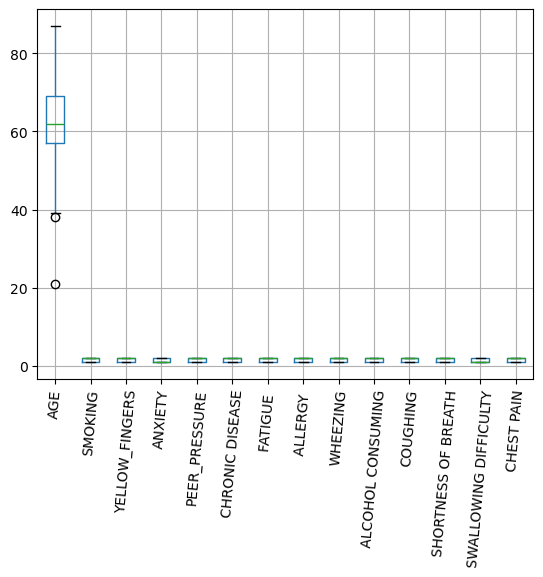

In [9]:
cancer.boxplot()
plt.xticks(rotation=85)
plt.show()

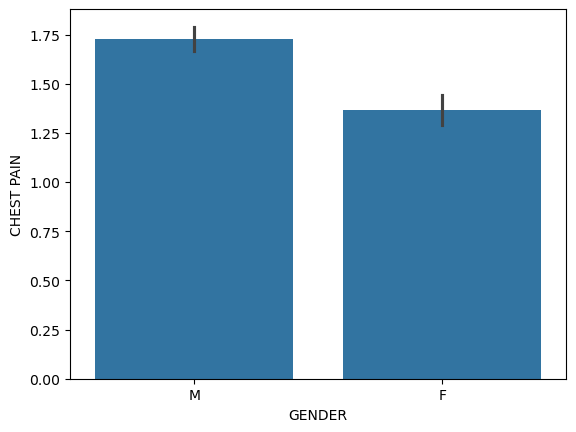

In [10]:
sns.barplot(x='GENDER',y='CHEST PAIN',data=cancer)
plt.show()

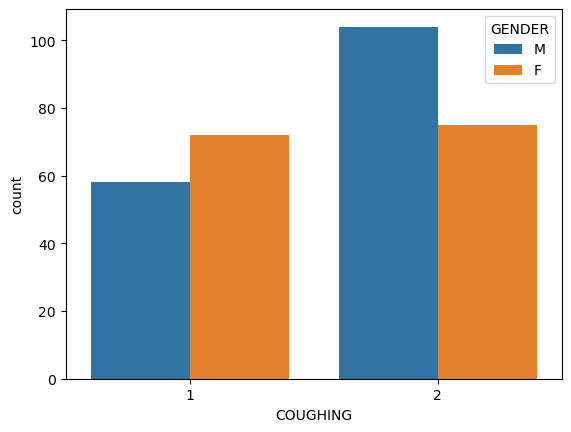

In [11]:
sns.countplot(x='COUGHING',data=cancer,hue='GENDER')
plt.show()

In [12]:
df=cancer.select_dtypes(include='number')


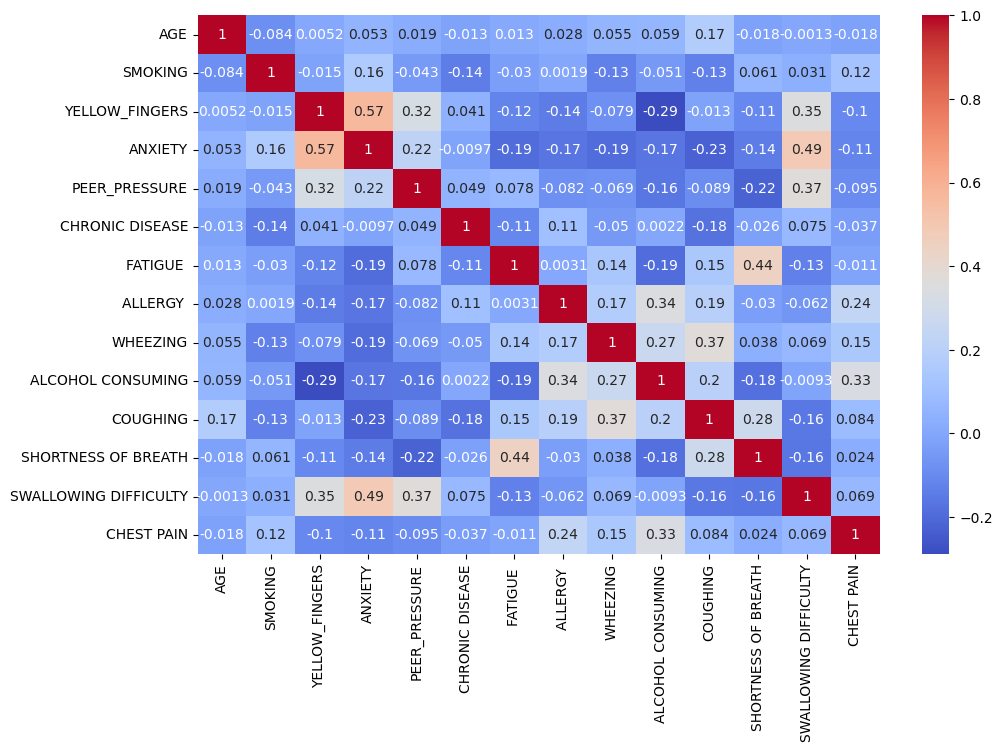

In [13]:
plt.figure(figsize=(11,7))
df1=df.corr()
sns.heatmap(df1,annot=True,cmap='coolwarm')
plt.show()

In [14]:
cancer

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [15]:
le=LabelEncoder()
cancer['LUNG_CANCER']=le.fit_transform(cancer['LUNG_CANCER'])
cancer

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,1
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,1
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,1
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,1


In [16]:
cancer['GENDER']=le.fit_transform(cancer['GENDER'])
cancer

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,0,56,1,1,1,2,2,2,1,1,2,2,2,2,1,1
305,1,70,2,1,1,1,1,2,2,2,2,2,2,1,2,1
306,1,58,2,1,1,1,1,1,2,2,2,2,1,1,2,1
307,1,67,2,1,2,1,1,2,2,1,2,2,2,1,2,1


In [17]:
cancer.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER'],
      dtype='object')

In [18]:
scaler=RobustScaler()
cols=['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN']
sc=scaler.fit_transform(cancer[cols])
sc

array([[ 0.        ,  0.58333333, -1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [-1.        , -0.25      , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        , -0.33333333,  0.        , ..., -1.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.41666667,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -1.        , ..., -1.        ,
         1.        , -1.        ]])

In [19]:
cancer[['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN']]=pd.DataFrame(sc,columns=cols)

In [20]:
x=cancer.drop(['LUNG_CANCER'],axis=1)
x

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,0.0,0.583333,-1.0,0.0,1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.000000,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,0.0,1.0,0.0
2,-1.0,-0.250000,-1.0,-1.0,0.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0
3,0.0,0.083333,0.0,0.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,1.0,0.0
4,-1.0,0.083333,-1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0,0.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,-1.0,-0.500000,-1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,1.0,-1.0
305,0.0,0.666667,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
306,0.0,-0.333333,0.0,-1.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
307,0.0,0.416667,0.0,-1.0,1.0,-1.0,-1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0


In [21]:
y=cancer['LUNG_CANCER']
y.head(10)

0    1
1    1
2    0
3    0
4    0
5    1
6    1
7    1
8    0
9    1
Name: LUNG_CANCER, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
model=LogisticRegression()
model.fit(x_train,y_train)


LogisticRegression()

In [27]:
y_pred=model.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
acc_1=accuracy_score(y_test,y_pred)
acc_1

0.967741935483871

In [30]:
model1=RandomForestClassifier()
model1.fit(x_train,y_train)

RandomForestClassifier()

In [31]:
y_pred=model1.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [32]:
r2_2=accuracy_score(y_test,y_pred)
r2_2

0.967741935483871

In [33]:
new_df=[[0.0,0.583333,-1.0,0.0,1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0]]
new_df

[[0.0,
  0.583333,
  -1.0,
  0.0,
  1.0,
  -1.0,
  -1.0,
  0.0,
  -1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0]]

In [34]:
prediction=model.predict(new_df)
prediction

array([1])

In [35]:
from sklearn.tree import DecisionTreeClassifier
model_3=DecisionTreeClassifier(criterion='gini',random_state=42)

In [36]:
model_3=DecisionTreeClassifier()
model_3.fit(x_train,y_train)

DecisionTreeClassifier()

In [37]:
y_pred=model_3.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [38]:
accuracy_3=accuracy_score(y_test,y_pred)
accuracy_3

0.9516129032258065

In [39]:
arr=x.iloc[0].tolist()
print(arr)

[0.0, 0.5833333333333334, -1.0, 0.0, 1.0, -1.0, -1.0, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]


In [40]:
prediction=model.predict(new_df)
prediction

array([1])

In [41]:
from sklearn.svm import SVC

In [42]:
svr_lin=SVC(kernel='linear')

In [43]:
svr_lin.fit(x_train,y_train)

SVC(kernel='linear')

In [44]:
ypred_svr=svr_lin.predict(x_test)


In [45]:
accuracy_4=accuracy_score(y_test,ypred_svr)
accuracy_4

0.967741935483871

In [46]:
svr_bin=SVC(kernel='rbf')

In [47]:
svr_bin.fit(x_train,y_train)

SVC()

In [48]:
ypred_rbf=svr_bin.predict(x_test)

In [49]:
accuracy_rbf=accuracy_score(y_test,ypred_rbf)
accuracy_rbf

0.967741935483871

In [50]:
from sklearn.neighbors import KNeighborsClassifier

In [51]:
metrics_k=[]
neighbors=np.arange(3,15)

In [52]:
for i in neighbors:
    knc=KNeighborsClassifier(n_neighbors=i,metric='euclidean')
    knc.fit(x_train,y_train)
    y_prediction=knc.predict(x_test)
    accuracy=accuracy_score(y_test,y_prediction)
    metrics_k.append(accuracy)

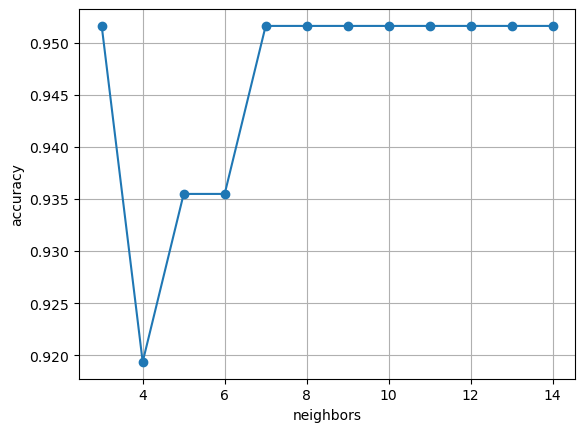

In [53]:
plt.plot(neighbors,metrics_k,'o-')
plt.xlabel('neighbors')
plt.ylabel('accuracy')
plt.grid()
plt.show()


In [54]:
knc=KNeighborsClassifier(n_neighbors=10,metric='euclidean')
knc.fit(x_train,y_train)
y_prediction=knc.predict(x_test)
accuracy_5=accuracy_score(y_test,y_prediction)
metrics_k.append(accuracy_5)

In [55]:
accuracy_5

0.9516129032258065

In [56]:
from xgboost import XGBClassifier

In [57]:
xgb_model=XGBClassifier()



In [58]:
xgb_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [59]:
y_pred_b=xgb_model.predict(x_test)

In [60]:
acc_6=accuracy_score(y_test,y_pred_b)
acc_6

0.9838709677419355

In [61]:
#pip install CatBoost

In [62]:
#pip install LightGBM

In [63]:
from catboost import CatBoostClassifier

In [64]:
cat=CatBoostClassifier()
cat.fit(x_train,y_train)

Learning rate set to 0.00567
0:	learn: 0.6877572	total: 153ms	remaining: 2m 32s
1:	learn: 0.6818724	total: 155ms	remaining: 1m 17s
2:	learn: 0.6767120	total: 157ms	remaining: 52.1s
3:	learn: 0.6712921	total: 158ms	remaining: 39.4s
4:	learn: 0.6658932	total: 160ms	remaining: 31.8s
5:	learn: 0.6594878	total: 162ms	remaining: 26.8s
6:	learn: 0.6535221	total: 165ms	remaining: 23.3s
7:	learn: 0.6476477	total: 166ms	remaining: 20.6s
8:	learn: 0.6423717	total: 167ms	remaining: 18.4s
9:	learn: 0.6372215	total: 169ms	remaining: 16.8s
10:	learn: 0.6318971	total: 171ms	remaining: 15.4s
11:	learn: 0.6259798	total: 172ms	remaining: 14.2s
12:	learn: 0.6212852	total: 173ms	remaining: 13.2s
13:	learn: 0.6145742	total: 175ms	remaining: 12.3s
14:	learn: 0.6088398	total: 176ms	remaining: 11.6s
15:	learn: 0.6047908	total: 179ms	remaining: 11s
16:	learn: 0.5992252	total: 180ms	remaining: 10.4s
17:	learn: 0.5942251	total: 181ms	remaining: 9.9s
18:	learn: 0.5898223	total: 183ms	remaining: 9.44s
19:	learn: 0.

In [65]:
y_pred_f=cat.predict(x_test)
y_pred_f

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [66]:
accuracy_7=accuracy_score(y_test,y_pred_f)
accuracy_7

0.967741935483871

In [67]:
from lightgbm import LGBMClassifier

In [68]:
gbm=LGBMClassifier()
gbm.fit(x_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 210, number of negative: 37
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000748 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 58
[LightGBM] [Info] Number of data points in the train set: 247, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.850202 -> initscore=1.736190
[LightGBM] [Info] Start training from score 1.736190
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

LGBMClassifier()

In [69]:
y_pred_r=gbm.predict(x_test)
y_pred_r

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [70]:
accuracy_8=accuracy_score(y_test,y_pred_r)
accuracy_8

0.9838709677419355

In [71]:
gbc=GradientBoostingClassifier()
gbc.fit(x_train,y_train)

GradientBoostingClassifier()

In [72]:
y_pred_gbc=gbc.predict(x_test)

In [73]:
r2_8=accuracy_score(y_test,y_pred_gbc)
r2_8

0.9516129032258065

In [74]:
from tabulate import tabulate 

In [75]:
table=[['Model','Accuracy'],['Logistic',acc_1],
       [ "Random Forest",r2_2],['Decision Tree',accuracy_3],
       ['SVC_linear',accuracy_4],['SVC_nonlinear',accuracy_rbf],
       ['KNeighborsClassifier',accuracy_5],['XGBClassifier',acc_6],
       ['CatBoostClassifier',accuracy_7],['LGBMClassifier',accuracy_8],
       ['GradientBoosting',r2_8]]
print(tabulate(table,headers='firstrow',tablefmt='fancy_grid'))

╒══════════════════════╤════════════╕
│ Model                │   Accuracy │
╞══════════════════════╪════════════╡
│ Logistic             │   0.967742 │
├──────────────────────┼────────────┤
│ Random Forest        │   0.967742 │
├──────────────────────┼────────────┤
│ Decision Tree        │   0.951613 │
├──────────────────────┼────────────┤
│ SVC_linear           │   0.967742 │
├──────────────────────┼────────────┤
│ SVC_nonlinear        │   0.967742 │
├──────────────────────┼────────────┤
│ KNeighborsClassifier │   0.951613 │
├──────────────────────┼────────────┤
│ XGBClassifier        │   0.983871 │
├──────────────────────┼────────────┤
│ CatBoostClassifier   │   0.967742 │
├──────────────────────┼────────────┤
│ LGBMClassifier       │   0.983871 │
├──────────────────────┼────────────┤
│ GradientBoosting     │   0.951613 │
╘══════════════════════╧════════════╛


In [77]:
from sklearn.model_selection import GridSearchCV

In [78]:
model_y=LGBMClassifier()

In [79]:
param_grid = {'learning_rate': [0.01, 0.05, 0.1],'max_depth': [-1, 3, 5, 7], 
                      'n_estimators': [100, 200, 300] }


In [81]:
grid_search=GridSearchCV(model_y,param_grid,cv=5)
grid_search.fit(x_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 168, number of negative: 29
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000451 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54
[LightGBM] [Info] Number of data points in the train set: 197, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.852792 -> initscore=1.756668
[LightGBM] [Info] Start training from score 1.756668
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

GridSearchCV(cv=5, estimator=LGBMClassifier(),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [-1, 3, 5, 7],
                         'n_estimators': [100, 200, 300]})

In [82]:
print('best_parameters:',grid_search.best_params_)

best_parameters: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200}


In [83]:
finalmodel=LGBMClassifier(n_estimators=200, learning_rate=0.05,max_depth=-1)
finalmodel.fit(x_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 210, number of negative: 37
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 58
[LightGBM] [Info] Number of data points in the train set: 247, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.850202 -> initscore=1.736190
[LightGBM] [Info] Start training from score 1.736190
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

LGBMClassifier(learning_rate=0.05, n_estimators=200)

In [84]:
y_pred_jk=finalmodel.predict(x_test)

In [85]:
final_acc=accuracy_score(y_test,y_pred_jk)
final_acc

0.9838709677419355